In [548]:
from google.colab import drive # remove the cell if not using colab
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [549]:
import pandas as pd
import numpy as np
from pathlib import Path
base_path = Path('/content/drive/MyDrive/Colab Notebooks/EDA_zadanie') # change path here!

In [550]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.dummy import DummyClassifier
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support, classification_report, ConfusionMatrixDisplay
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

# Klasyfikacja pasażerów Titanica
Nie wiemy czy dla DiCaprio było miejsce na drzwiach, ale wiemy że grdyby był tam Wojfer87 to by z nimi wyciskał pompki na górze lodowej. Teraz twoja pora na wyciskanie.
#Twoje zadnie to:
**stworzenie modelu przewidującego szanse przeżycia katastrofy Titanica**.

![https://i1.jbzd.com.pl/contents/2025/11/normal/v5Fth4DcPpPPxSrXQ5rCbAgZ8EifWiiF.png](https://i1.jbzd.com.pl/contents/2025/11/normal/v5Fth4DcPpPPxSrXQ5rCbAgZ8EifWiiF.png "Wojfer")



#### Twoim celem będzie jest wytrenowanie modeli do klasyfikacji każdego pasażera Titanica jako ofiary (0) lub osoby, która przeżyła (1).

Poniżej znajdziesz pytania, które mogą być pomocne w zadaniu:

- Czego nauczyło Cię o badanym zbiorze danych poprzednie zadanie? Jak możesz wykorzystać wyciągnięte z niego wnioski w procesie tworzenia modelu?
- Jak przeprowadzenie standaryzacji danych może wpływać na zachowanie modelu?
- Co mój model robi i w jaki sposób?
- Jak nie przetrenować wybranego modelu?
- Jaki wynik klasyfikacji możemy uznać za *dobry*?


Wymagania:
- Wypisz obserwacje z pierwszego zadania, które pomogą Ci w tym. Co było przydatne, a co okazało się bezużyteczne?
- [Nie doprowadź](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) do ~~przecieku statku~~ wycieku danych (np. nie ucz modelu na danych testowych). Nauczone modele odpal na danych treningowych i testowych - opisz uzyskane wyniki.
- Stwórz baseline, czyli dla porównania sprawdź jak z zadaniem radzi sobie [Dummy Classifier](https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html) (jeśli Twój docelowy model radzi sobie gorzej - uciekaj)
- Przeprowadź badania na dwóch wybranych modelach uczenia maszynowego (np. spośród: drzew decyzyjnych, SVM, MLP, KNN, z gwiazdką [XGBoost](https://xgboost.readthedocs.io/en/stable))
- W badaniach użyj wybranych metryk. Wybór uzasadnij.
- Dla każdego modelu wybierz co najmniej dwa hiperparametry i przeprowadź badania zależności wyników metryk od wartości hiperparametrów. Zwizualizuj wszystko ładnie, zastanów się dlaczego tak mogło być i wyciągnij i wypisz wnioski.
- Podsumuj przeprowadzone badania, wypisz wnioski.

Niezmiennie, zadbaj o czytelność kodu i nazewnictwo zmiennych. Jeśli jakiś wycinek kodu się powtarza, to wyodrębnij go do funkcji. Postaraj się zamieszczać swoje wnioski w postaci komentarza `Markdown`.

Jeśli chcesz, możesz sprawdzić (przyjmując pewne założenia), jakie byłyby Twoje szanse na Titanicu.

Uwaga! Jeśli Titanic to dla Ciebie nic i baaaaardzo chcesz to możesz w ramach tego zadania zająć się [bardziej wymagającym](https://archive.ics.uci.edu/dataset/365/polish+companies+bankruptcy+data) zbiorem.

In [551]:
titanic_df = pd.read_csv(base_path / 'titanic.csv', index_col='PassengerId')

In [552]:
titanic_df['Cabin'].str[0].unique()

array([nan, 'C', 'E', 'G', 'D', 'A', 'B', 'F', 'T'], dtype=object)

1. Wnioski z poprzedniego zadadania:
- `Ticket` do usunięcia.
- warto stworzyć nowe `FamilySize`: `Parch` + `SibSp` + 1. Postanowiłem ostatecznie usunąć `Parch` i `SibSp` bo mimo że mają nieco różną zależność z przeżywalnością (np. `Parch` osiąga lepsze wyniki dla wartości 3 niż `SibSp`) to jest to bardzo mało istotne bo dotyczy nielicznej ilości osób na pokładzie. Usuwając te dwie kolumny oszczędzamy modelowi trochę szumu a niewiele tracimy.
- warto zastąpić `Name` kolumną `Title` (dane wyciągnięte z `Name`; rzadkie tytuły zastępujemy klasą `Other`)
- warto zastąpić `Cabin` kolumną `HasCabin` (gdzie brak danych oznacza `HasCabin` = 0)
- braki w `Age` uzupełniamy medianą opartą o `Title` i `Pclass`
- braki w `Fare` uzupełniamy medianą opartą o `Pclass` i `Embarked`
- braki w `Embarked` uzupełniamy dominantą bo jest ich bardzo mało
- `Sex` kodujemy jako 0 albo 1

In [553]:
# Ticket
titanic_df = titanic_df.drop(columns=['Ticket'])

In [554]:
# FamiliSize
titanic_df['FamilySize'] = titanic_df['Parch'] + titanic_df['SibSp'] + 1
titanic_df.drop(columns=['Parch', 'SibSp'], inplace=True)

In [555]:
# Name -> Title
def get_title(name):
  rare_titles = ['Don', 'Rev', 'Dr', 'Mme', 'Ms', 'Major', 'Lady', 'Sir', 'Mlle', 'Col', 'Capt', 'Countess', 'Jonkheer']
  for word in name.split(" "):
    if word.endswith("."):
      title = word[:-1]
      if title in ['Mlle', 'Ms']:
        return 'Miss'
      if title == 'Mme':
        return 'Mrs'
      if title in rare_titles:
        return 'Other'
      return title
  return None

titanic_df['Title'] = titanic_df['Name'].apply(lambda x: get_title(x))
titanic_df.drop(columns=['Name'], inplace=True)

In [556]:
# Cabin -> HasCabin
titanic_df['HasCabin'] = titanic_df['Cabin'].notna().astype(int)
titanic_df.drop(columns=['Cabin'], inplace=True)

In [557]:
# Sex
titanic_df['Sex'] = titanic_df['Sex'].map({'female': 1, 'male': 0}).astype(int)

Przed zmianami z medianą i dominantą podzielę dane na zbiór treningowy i testowy by zapobiec data leakage

In [558]:
X_train, X_test, y_train, y_test = train_test_split(titanic_df.drop('Survived', axis=1), titanic_df['Survived'], train_size=.8, shuffle=True, random_state=2137)

In [559]:
# Age, Fare
def fill_na_with_grouped_median(X_train, X_test, target_category, grouping_cols):
  X_train, X_test = X_train.copy(), X_test.copy() # work on copies so the function is pure
  median_dict = X_train.groupby(grouping_cols)[target_category].median().to_dict()
  median_global = X_train[target_category].median() # backup if theres no data for certain grouping

  if len(grouping_cols) == 1:
    keys_train = X_train[grouping_cols[0]]
    keys_test = X_test[grouping_cols[0]]
  else:
    keys_train = pd.Series(zip(*[X_train[col] for col in grouping_cols]), index=X_train.index)
    keys_test = pd.Series(zip(*[X_test[col] for col in grouping_cols]), index=X_test.index)

  # fill Na with values from median_dict or median_global using map to create a series of medians for all indexes
  X_train[target_category] = X_train[target_category].fillna(keys_train.map(median_dict)).fillna(median_global)
  X_test[target_category] = X_test[target_category].fillna(keys_test.map(median_dict)).fillna(median_global)
  return X_train, X_test

X_train, X_test = fill_na_with_grouped_median(X_train, X_test, 'Age', ['Title', 'Pclass'])
X_train, X_test = fill_na_with_grouped_median(X_train, X_test, 'Fare', ['Embarked', 'Pclass'])


In [560]:
# Embarked
embarked_mode = X_train['Embarked'].mode()[0]

X_train['Embarked'] = X_train['Embarked'].fillna(embarked_mode)
X_test['Embarked'] = X_test['Embarked'].fillna(embarked_mode)

X_train.isna().sum().sum() + X_test.isna().sum().sum()

np.int64(0)

In [561]:
X_train.head()

,Pclass,Sex,Age,Fare,Embarked,FamilySize,Title,HasCabin
PassengerId,,,,,,,,
402,3,0,26.00,8.0500,S,1,Mr,0
874,3,0,47.00,9.0000,S,1,Mr,0
300,1,1,50.00,247.5208,C,2,Mrs,1
306,1,0,0.92,151.5500,S,4,Master,1
274,1,0,37.00,29.7000,C,2,Mr,1


Przejdźmy do zakodowania kolumn kategorycznych za pomocą one hot encoding. Świadomie pomijam parametr drop='first' bo może on wpłynąć negatywnie na niektóre modele

In [562]:
cat_cols = ['Embarked', 'Title']

enc = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
enc.set_output(transform="pandas")

encoded_train = enc.fit_transform(X_train[cat_cols])
encoded_test = enc.transform(X_test[cat_cols])

X_train.drop(columns=cat_cols, inplace=True)
X_test.drop(columns=cat_cols, inplace=True)


X_train = pd.concat([X_train, encoded_train], axis=1)
X_test = pd.concat([X_test, encoded_test], axis=1)

Dane zostały zakodowane jako float ale to nie problem.

Teraz sprawdźmy DummyClassifier

In [563]:
model = DummyClassifier(strategy='uniform')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
confusion_matrix(y_test, y_pred)

              precision    recall  f1-score   support

           0       0.57      0.43      0.49       107
           1       0.38      0.51      0.44        72

    accuracy                           0.46       179
   macro avg       0.47      0.47      0.46       179
weighted avg       0.49      0.46      0.47       179



array([[46, 61],
       [35, 37]])

Trzeba jeszcze zastanowić się nad skalowaniem wartości liczbowych.

In [564]:
X_train[['Fare', 'Age', 'FamilySize']].describe()

,Fare,Age,FamilySize
count,712.000000,712.000000,712.000000
mean,32.626129,29.457177,1.880618
std,51.655419,13.130000,1.602061
min,0.000000,0.420000,1.000000
25%,8.050000,21.000000,1.000000
50%,13.500000,27.000000,1.000000
75%,33.000000,37.000000,2.000000
max,512.329200,74.000000,11.000000


`Fare` ma bardzo mocny outlier o wartości 512 stąd najlepiej będzie użyć robust scaler. Podobnie w przypadku `FamiliSize` które ma asymetryczny rozkład. W przypadku `Age` zastosuję standard scaler bo rozkład przypomina normalny.

Stwierdziłem że porównam trzy modele:
1. SVM - dzieli klasy dobierając jak najwięszke marginesy
2. drzewo decyzyjne - tworzy serie warunków które starają się kategoryzować dane, ilość danych rośnie bardzo szybko wraz z głębokością
3. XGBoost - tworzy wiele płytkich drzew decyzyjnych starając się każdym następnym naprawić błędy poprzedniego

Żeby sprawdzić jaki model poradzi sobie najlepiej i jednocześnie uniknąć wycieku danych trzeba przeskalować dane liczbowe po podziale na dane do trenowania i walidacji, więc użyję pipeline'ów. Dla każdego trzeba najpierw zdefiniować operacje typu transform a później finalny estimator.

Dane warto przeskalować ze względu na modele liniowe lub liczących odległości takich jak KNN i SVM a dla tych opartych na drzewach nie zrobią dużej różnic.

By zapobiec przetrenowaniu zadbam o kilka rzeczy:
1. Kontrola hiperparametrów:
  - w przypadku drzew `min_samples_leaf`, `max_depth` by liście nie były zbyt konkretne
  - w przypadku SVM `C` odpowiada za dawanie kar za zbyt mocne poleganie na jednej cesze (mniejsze C to silniejsza regularyzacja i prostszy model)
2. Kroswalidacja (poniżej)
3. Wzbogacenie danych (np. kolumny `Title`, `HasCabin`) i usunięcie zbędnych informacji (np. `Parch` + `SibSp` -> `FamiliSize`).

In [565]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import GridSearchCV
import pandas as pd

preprocessor = ColumnTransformer(
    transformers=[
        ('robust', RobustScaler(), ['Fare', 'FamilySize']),
        ('standard', StandardScaler(), ['Age'])
    ],
    remainder='passthrough' # zostawiamy wszystkie kolumny
)

# pipeline wymusza użycia przedrostka classifier__ przed każdym paramem
models = [
    {
        'name': 'DecisionTree',
        'model': DecisionTreeClassifier(random_state=2137),
        'params': {
            'classifier__max_depth': [2, 3, 5, 10, None],
            'classifier__criterion': ['gini', 'entropy'],
            'classifier__min_samples_leaf': [1, 3, 5],
        }
    },
    {
        'name': 'SVM',
        'model': SVC(random_state=2137),
        'params': {
            'classifier__C': [0.1, 1, 10],
            'classifier__kernel': ['rbf', 'linear']
        }
    },
    {
        'name': 'XGBoost',
        'model': XGBClassifier(random_state=2137),
        'params': {
            'classifier__n_estimators': [50, 100, 200],

            'classifier__max_depth': [3, 5, 7], # płytkie drzewa

            'classifier__learning_rate': [0.01, 0.1, 0.2]
        }
    }
]

results = []

for m in models:
    # dla każdego modelu tworzymy pipe i później wrzucamy go całego do GridSearchCV
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', m['model'])
    ])

    grid = GridSearchCV(pipe, m['params'], cv=5, scoring='accuracy')

    grid.fit(X_train, y_train)

    results.append({
        'model': m['name'],
        'best score': grid.best_score_,
        'best params': grid.best_params_,
        'best pipeline': grid.best_estimator_,
        'cv_results': grid.cv_results_
    })

results_df = pd.DataFrame(results).drop(columns=['cv_results']).sort_values(by='best score', ascending=False)
pd.set_option('display.max_colwidth', None) # żeby wypisał wszystkie hiperparametry
results_df

,model,best score,best params,best pipeline
0,DecisionTree,0.849729,"{'classifier__criterion': 'entropy', 'classifier__max_depth': 5, 'classifier__min_samples_leaf': 5}","(ColumnTransformer(remainder='passthrough',\n transformers=[('robust', RobustScaler(),\n ['Fare', 'FamilySize']),\n ('standard', StandardScaler(), ['Age'])]), DecisionTreeClassifier(criterion='entropy', max_depth=5, min_samples_leaf=5,\n random_state=2137))"
1,SVM,0.838530,"{'classifier__C': 10, 'classifier__kernel': 'rbf'}","(ColumnTransformer(remainder='passthrough',\n transformers=[('robust', RobustScaler(),\n ['Fare', 'FamilySize']),\n ('standard', StandardScaler(), ['Age'])]), SVC(C=10, random_state=2137))"
2,XGBoost,0.837122,"{'classifier__learning_rate': 0.01, 'classifier__max_depth': 5, 'classifier__n_estimators': 200}","(ColumnTransformer(remainder='passthrough',\n transformers=[('robust', RobustScaler(),\n ['Fare', 'FamilySize']),\n ('standard', StandardScaler(), ['Age'])]), XGBClassifier(base_score=None, booster=None, callbacks=None,\n colsample_bylevel=None, colsample_bynode=None,\n colsample_bytree=None, device=None, early_stopping_rounds=None,\n enable_categorical=True, eval_metric=None, feature_types=None,\n feature_weights=None, gamma=None, grow_policy=None,\n importance_type=None, interaction_constraints=None,\n learning_rate=0.01, max_bin=None, max_cat_threshold=None,\n max_cat_to_onehot=None, max_delta_step=None, max_depth=5,\n max_leaves=None, min_child_weight=None, missing=nan,\n monotone_constraints=None, multi_strategy=None, n_estimators=200,\n n_jobs=None, num_parallel_tree=None, ...))"


## Wnioski z kroswalidacji
Wszystkie modele poradziły sobie powyżej baseline'u wyznaczonego przez DummyClassifier. Jednoczęśnie każdy przekroczył 80% co jest zadowalającym wynikiem.

Co ciekawe XGBoost poradził sobie słabiej niż możnaby oczekiwać. Prawdopodobnie jest to związane z małą ilością danych i ryzykiem przeuczenia o czym może świadczyć hiperparametr learning_rate wybrany na najniższym poziomie. Z moich testów wynika że przy niższym n_estimators model radzi sobie nieznacznie lepiej ale nadal nie wskakuje na pierwsze miejsce. To chyba za prosty dataset i klasyczne drzewo radzi sobie lepiej.

Przetestujmy najlepszy model i porównajmy jego wyniki na danych testowych i treningowych żeby sprawdzić czy nie doszło do przetrenowania.


              precision    recall  f1-score   support

           0       0.85      0.94      0.89       442
           1       0.88      0.73      0.80       270

    accuracy                           0.86       712
   macro avg       0.87      0.84      0.85       712
weighted avg       0.86      0.86      0.86       712

              precision    recall  f1-score   support

           0       0.80      0.91      0.85       107
           1       0.82      0.65      0.73        72

    accuracy                           0.80       179
   macro avg       0.81      0.78      0.79       179
weighted avg       0.81      0.80      0.80       179



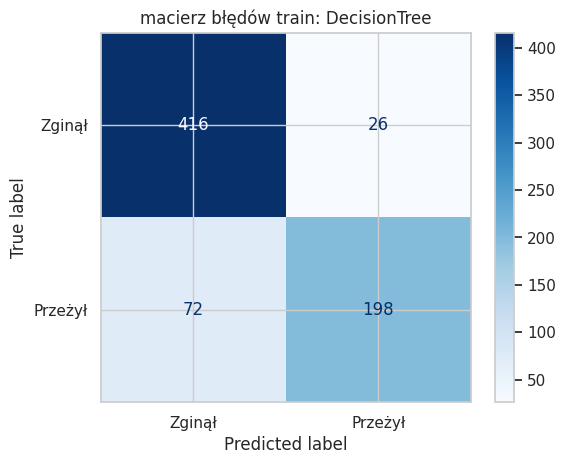

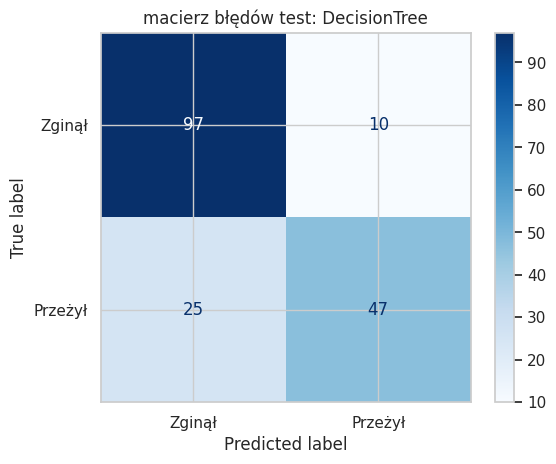

Score train: 0.862
Score test:   0.804


In [566]:
best_pipe = results_df.loc[0]['best pipeline']

y_pred_train = best_pipe.predict(X_train)
y_pred_test = best_pipe.predict(X_test)

# classification report
print(classification_report(y_train, y_pred_train))
print(classification_report(y_test, y_pred_test))

# confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_train,
    y_pred_train,
    display_labels=['Zginął', 'Przeżył'],
    cmap='Blues'
)
plt.title(f"macierz błędów train: {results_df.iloc[0]['model']}")
plt.show()
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_test,
    display_labels=['Zginął', 'Przeżył'],
    cmap='Blues'
)
plt.title(f"macierz błędów test: {results_df.iloc[0]['model']}")
plt.show()

# porównanie score
score_train = best_pipe.score(X_train, y_train)
score_test = best_pipe.score(X_test, y_test)

print(f"Score train: {score_train:.3f}")
print(f"Score test:   {score_test:.3f}")

Model na obu zbiorach danych zachowuje się bardzo podobnie, nieco większy wynik na zbiorze treningowym świadczy że nie doszło do przetrenowania.

Z macierzy widać że model przeoczał wiele osób które przeżyły. Może to wynikać częściowo z tego że ocalałych było zwyczajnie dużo mniej w zbiorze danych.

In [567]:
plot_configs = {
    'DecisionTree': {
        'x': 'param_classifier__max_depth',
        'hue': 'param_classifier__min_samples_leaf',
        'scale': 'linear'
    },
    'SVM': {
        'x': 'param_classifier__C',
        'hue': 'param_classifier__kernel',
        'scale': 'log'
    },
    'XGBoost': {
        'x': 'param_classifier__n_estimators',
        'hue': 'param_classifier__learning_rate',
        'scale': 'linear'
    }
}

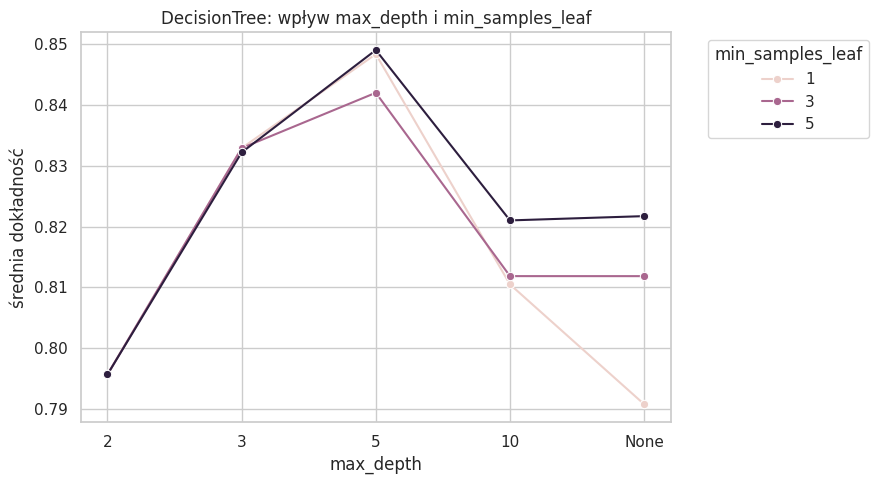

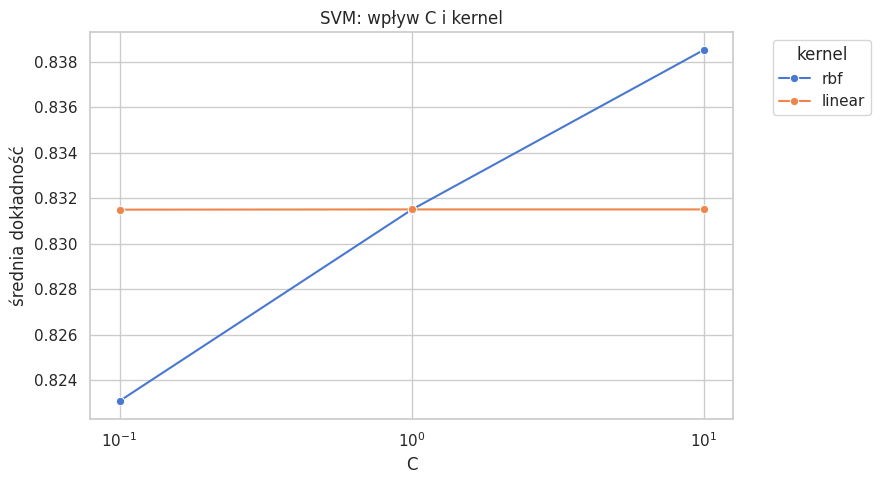

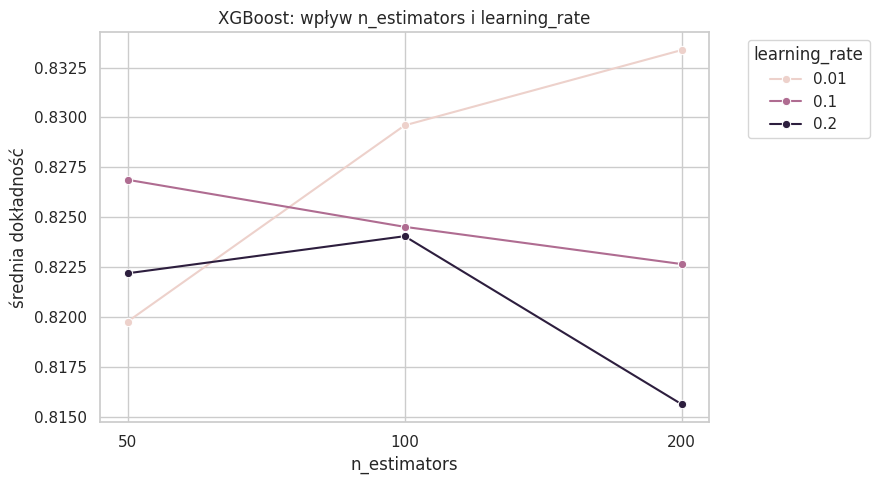

In [568]:
sns.set_theme(style="whitegrid", palette="muted")

for res_row in results:
    nazwa_modelu = res_row['model']

    if nazwa_modelu in plot_configs:
        cfg = plot_configs[nazwa_modelu]

        cv_df = pd.DataFrame(res_row['cv_results'])

        plt.figure(figsize=(9, 5))

        # skala logarytmiczna dla liczb, tekstowa dla reszty, by uniknąć błędów z None
        if cfg['scale'] == 'log':
            cv_df[cfg['x']] = cv_df[cfg['x']].astype(float)
            plt.xscale('log')
        else:
            cv_df[cfg['x']] = cv_df[cfg['x']].fillna('None').astype(str)

        sns.lineplot(
            data=cv_df,
            x=cfg['x'],
            y='mean_test_score',
            hue=cfg['hue'],
            marker='o',
            errorbar=None
        )

        czysta_nazwa_x = cfg['x'].replace('param_classifier__', '')
        czysta_nazwa_hue = cfg['hue'].replace('param_classifier__', '')

        plt.title(f"{nazwa_modelu}: wpływ {czysta_nazwa_x} i {czysta_nazwa_hue}")
        plt.xlabel(czysta_nazwa_x)
        plt.ylabel('średnia dokładność')
        plt.legend(title=czysta_nazwa_hue, bbox_to_anchor=(1.05, 1), loc='upper left')

        plt.tight_layout()
        plt.show()

### Wnioski z analizy hiperparametrów
1. DecisionTree: wyraźnie wygrywa złoty środek pomiędzy przeuczeniem a niedouczeniem jeśli chodzi o `max_depth`. Im wyższe `min_samples_leaf` tym (do pewnego momentu) lepiej - zabezpiecza przed przeuczeniem.
2. SVM: nieliniowość pozwala modelowi osiągnąć pełny potencjał jeśli poluzujemy karę za błędy.
3. XGBoost: dla szybko uczących się modeli efektywność mocno spada gdy rośnie ilość drzew (rozdrobnienie skutkuje przeuczeniem). Dla odmiany powolne uczenie opłaca się jeśli damy modelowi wiele prób.


## Wnioski
Dla prostego datasetu prosty model okazał się najlepszy.

Poprawnie zgaduje w około 85% przypadkach co jest bardzo dobrym wynikiem patrząc na to że problem pojawił się głównie w przypadku osób o których było najmniej danych (ci którzy przeżyli).

Dobór hiperparametórw może gwałtownie wpłynąć na wynik modeli.